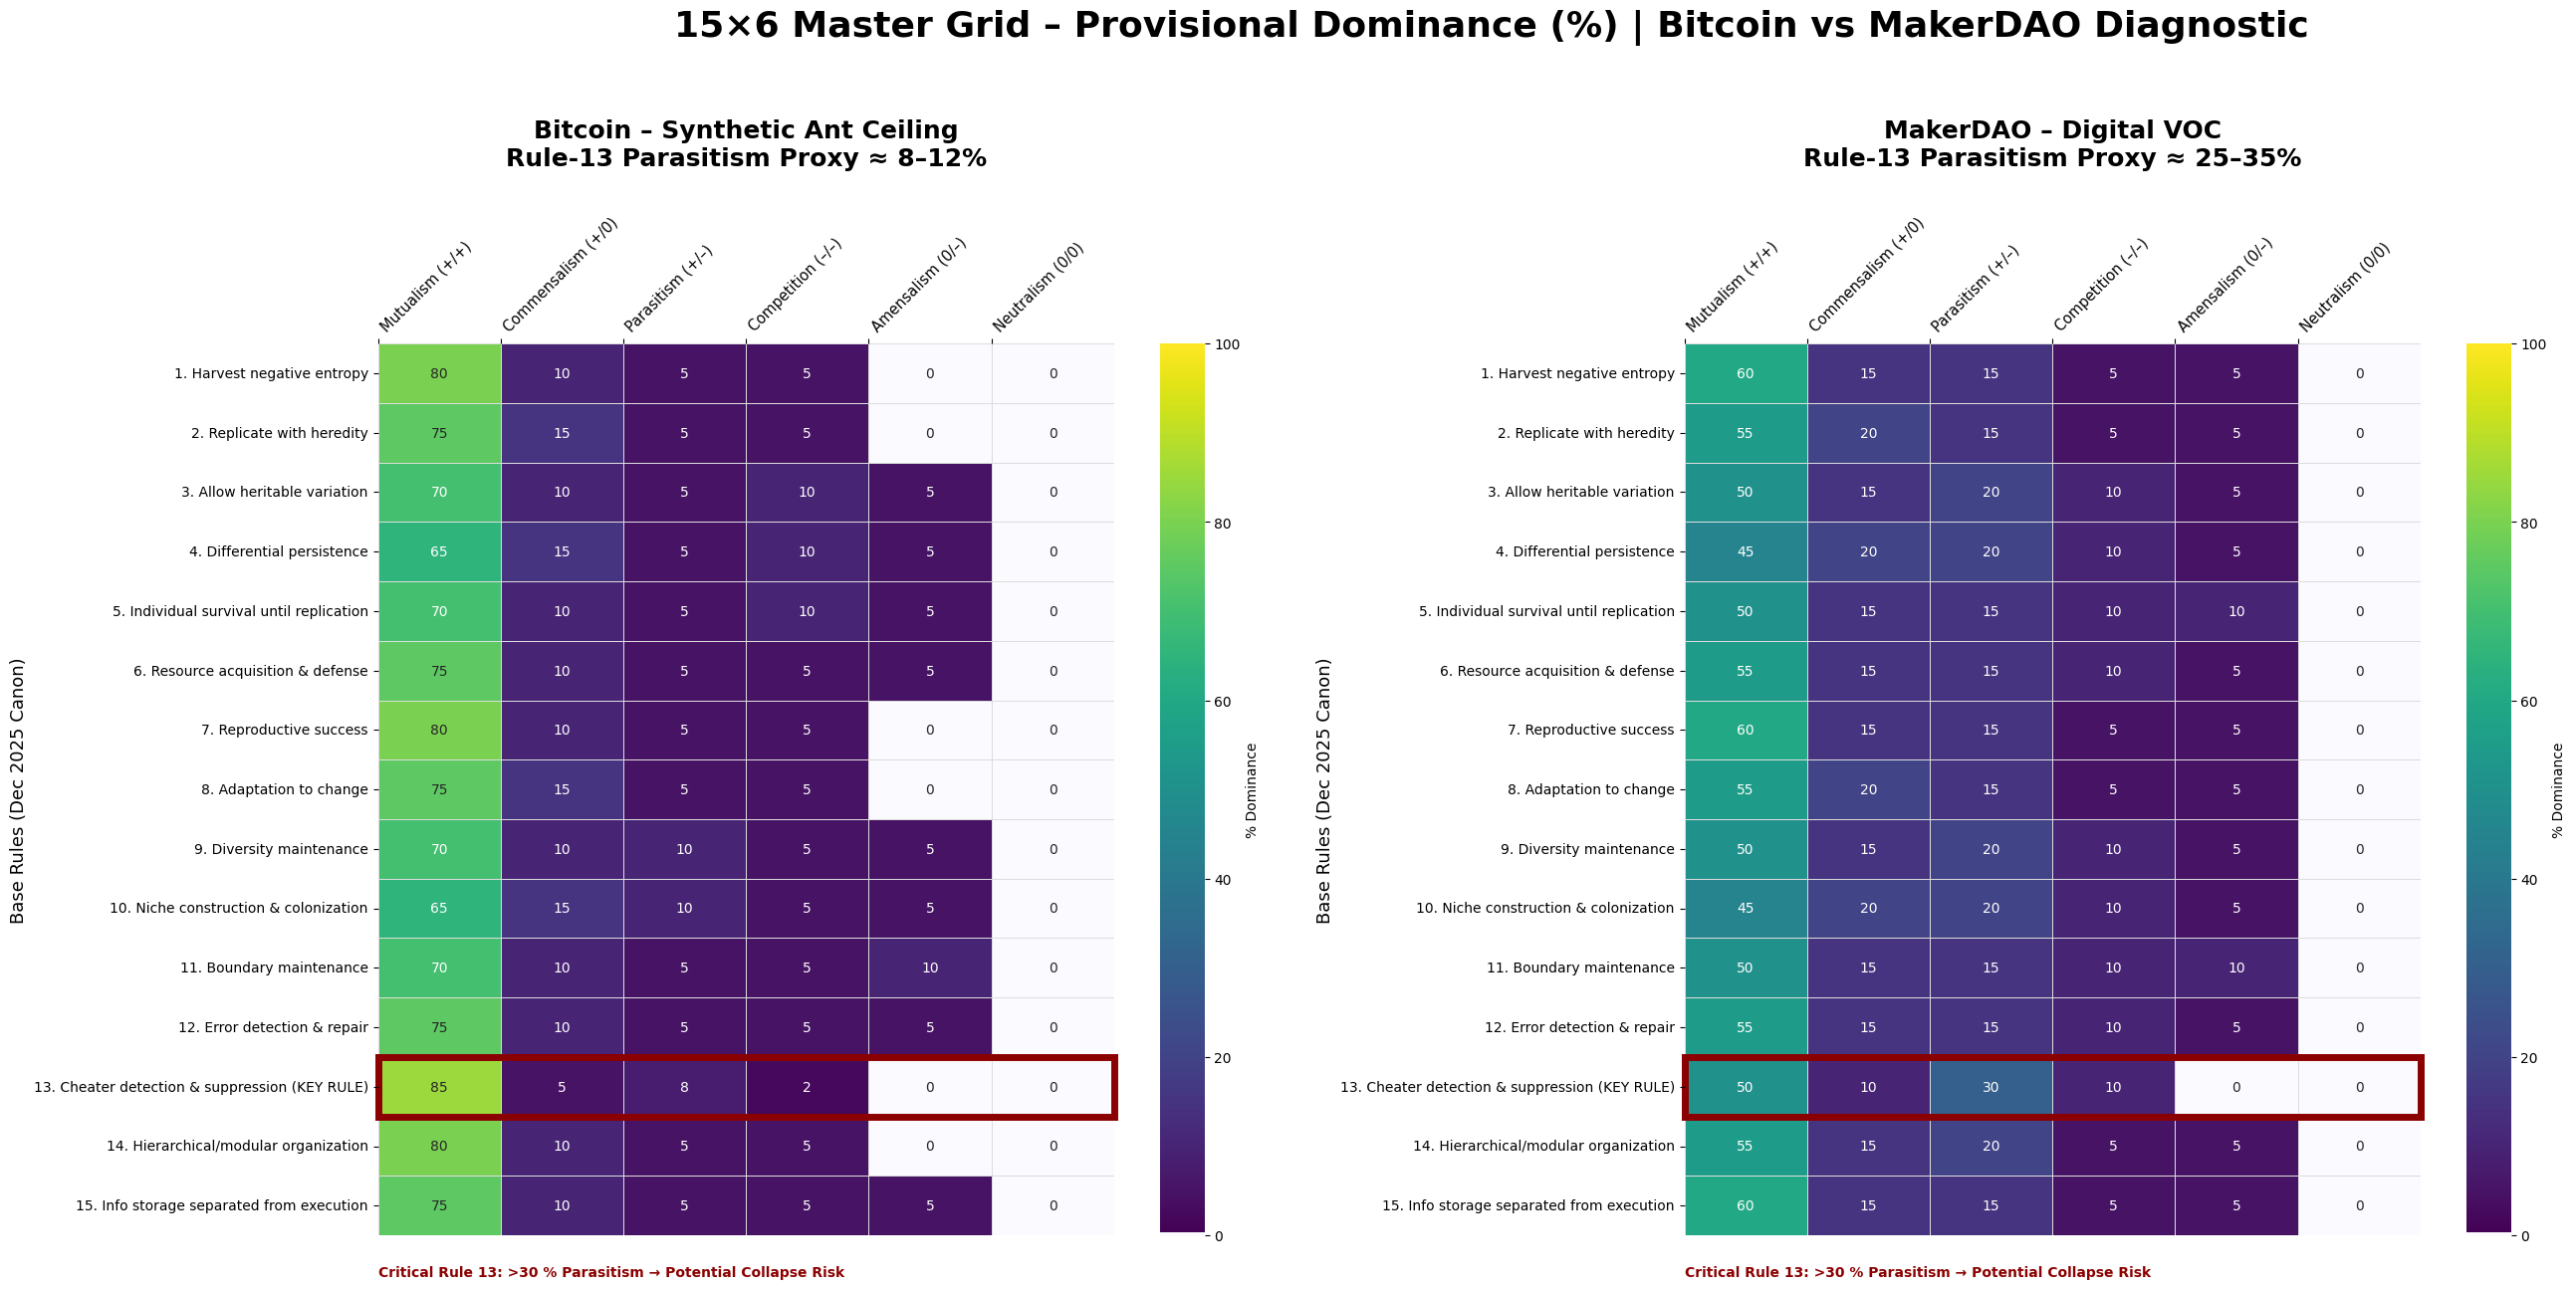

Saved: figures/bitcoin_vs_makerdao_heatmap_rc3_labels_fixed.png


In [15]:
# -*- coding: utf-8 -*-
"""bitcoin_vs_makerdao_heatmap_rc3_labels_fixed.py
Final fix: independent y-labels, explicit tick_params for MakerDAO y-axis."""

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# ────────────────────────────────────────────────
# 1. CANONICAL LABELS
# ────────────────────────────────────────────────
rules = [
    "1. Harvest negative entropy", "2. Replicate with heredity", "3. Allow heritable variation",
    "4. Differential persistence", "5. Individual survival until replication", "6. Resource acquisition & defense",
    "7. Reproductive success", "8. Adaptation to change", "9. Diversity maintenance",
    "10. Niche construction & colonization", "11. Boundary maintenance", "12. Error detection & repair",
    "13. Cheater detection & suppression (KEY RULE)", "14. Hierarchical/modular organization",
    "15. Info storage separated from execution"
]

moves = ["Mutualism (+/+)", "Commensalism (+/0)", "Parasitism (+/–)",
         "Competition (–/–)", "Amensalism (0/–)", "Neutralism (0/0)"]

# ────────────────────────────────────────────────
# 2. DOMINANCE MATRICES (your provisionals)
# ────────────────────────────────────────────────
bitcoin_dom = np.array([
    [80, 10,  5,  5,  0,  0],
    [75, 15,  5,  5,  0,  0],
    [70, 10,  5, 10,  5,  0],
    [65, 15,  5, 10,  5,  0],
    [70, 10,  5, 10,  5,  0],
    [75, 10,  5,  5,  5,  0],
    [80, 10,  5,  5,  0,  0],
    [75, 15,  5,  5,  0,  0],
    [70, 10, 10,  5,  5,  0],
    [65, 15, 10,  5,  5,  0],
    [70, 10,  5,  5, 10,  0],
    [75, 10,  5,  5,  5,  0],
    [85,  5,  8,  2,  0,  0],
    [80, 10,  5,  5,  0,  0],
    [75, 10,  5,  5,  5,  0]
])

makerdao_dom = np.array([
    [60, 15, 15,  5,  5,  0],
    [55, 20, 15,  5,  5,  0],
    [50, 15, 20, 10,  5,  0],
    [45, 20, 20, 10,  5,  0],
    [50, 15, 15, 10, 10,  0],
    [55, 15, 15, 10,  5,  0],
    [60, 15, 15,  5,  5,  0],
    [55, 20, 15,  5,  5,  0],
    [50, 15, 20, 10,  5,  0],
    [45, 20, 20, 10,  5,  0],
    [50, 15, 15, 10, 10,  0],
    [55, 15, 15, 10,  5,  0],
    [50, 10, 30, 10,  0,  0],
    [55, 15, 20,  5,  5,  0],
    [60, 15, 15,  5,  5,  0]
])

bitcoin_df  = pd.DataFrame(bitcoin_dom,  index=rules, columns=moves)
makerdao_df = pd.DataFrame(makerdao_dom, index=rules, columns=moves)

# ────────────────────────────────────────────────
# 3. COLORMAP & STYLE
# ────────────────────────────────────────────────
viridis_base = mpl.colormaps["viridis"]
newcolors = viridis_base(np.linspace(0, 1, 256))
newcolors[0, :] = [0.98, 0.98, 1, 1]
custom_map = LinearSegmentedColormap.from_list('FullSaturation', newcolors)
oxford_red = "#8B0000"

# ────────────────────────────────────────────────
# 4. DUAL PLOT WITH LABEL FIXES
# ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(26, 14), sharey=False)  # sharey=False → independent y labels

# Bitcoin left
sns.heatmap(bitcoin_df, annot=True, fmt=".0f", cmap=custom_map, vmin=0, vmax=100,
            linewidths=0.5, linecolor="#dddddd", cbar_kws={'label': '% Dominance', 'pad': 0.05}, ax=ax1)
ax1.set_title("Bitcoin – Synthetic Ant Ceiling\nRule-13 Parasitism Proxy ≈ 8–12%", fontsize=18, fontweight='bold', pad=35)
ax1.set_ylabel("Base Rules (Dec 2025 Canon)", fontsize=13)
ax1.xaxis.set_ticks_position('top')
ax1.set_xticks(np.arange(len(moves)))
ax1.set_xticklabels(moves, rotation=45, ha="left", fontsize=10.5)
ax1.tick_params(axis='y', labelleft=True, labelsize=10)
ax1.add_patch(plt.Rectangle((0, 12), 6, 1, fill=False, edgecolor=oxford_red, lw=5, clip_on=False))
ax1.text(0, 15.5, "Critical Rule 13: >30 % Parasitism → Potential Collapse Risk",
         fontsize=10, color=oxford_red, ha='left', va='top', fontweight='bold',
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# MakerDAO right – explicit label enforcement
sns.heatmap(makerdao_df, annot=True, fmt=".0f", cmap=custom_map, vmin=0, vmax=100,
            linewidths=0.5, linecolor="#dddddd", cbar_kws={'label': '% Dominance', 'pad': 0.05}, ax=ax2)
ax2.set_title("MakerDAO – Digital VOC\nRule-13 Parasitism Proxy ≈ 25–35%", fontsize=18, fontweight='bold', pad=35)
ax2.set_ylabel("Base Rules (Dec 2025 Canon)", fontsize=13)  # Explicitly set
ax2.xaxis.set_ticks_position('top')
ax2.set_xticks(np.arange(len(moves)))
ax2.set_xticklabels(moves, rotation=45, ha="left", fontsize=10.5)
ax2.tick_params(axis='y', which='both', labelleft=True, labelsize=10)  # FORCE y-labels on
ax2.add_patch(plt.Rectangle((0, 12), 6, 1, fill=False, edgecolor=oxford_red, lw=5, clip_on=False))
ax2.text(0, 15.5, "Critical Rule 13: >30 % Parasitism → Potential Collapse Risk",
         fontsize=10, color=oxford_red, ha='left', va='top', fontweight='bold',
         bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# Global layout
fig.suptitle("15×6 Master Grid – Provisional Dominance (%) | Bitcoin vs MakerDAO Diagnostic",
             fontsize=26, fontweight='bold', y=1.06)
plt.subplots_adjust(top=0.82, wspace=0.42, bottom=0.18, left=0.07, right=0.93)

plt.savefig("figures/bitcoin_vs_makerdao_heatmap_rc3_labels_fixed.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figures/bitcoin_vs_makerdao_heatmap_rc3_labels_fixed.png")